In [1]:
# Setup and Pipeline
import sys
import os
import warnings
import importlib
warnings.filterwarnings("ignore")
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

import src.preprocess
import src.features
import src.models
import src.visualization

importlib.reload(src.preprocess)
importlib.reload(src.features)
importlib.reload(src.models)
importlib.reload(src.visualization)

from src.preprocess import load_and_clean_data
from src.features import engineer_weather_features
from src.models import train_xgboost_model, generate_shap_explanation, train_prophet_model, plot_prophet_forecast
from src.visualization import plot_spatial_weather, plot_air_quality_correlation

print("Pipeline Successfully Loaded!")

Pipeline Successfully Loaded!


In [2]:
# Load and Clean
DATA_PATH = "../data/global_weather_repository.csv"
df = load_and_clean_data(DATA_PATH)
df = engineer_weather_features(df)
print(f"Data Shape: {df.shape}")
print(f"Anomalies Detected: {df['is_anomaly'].sum()}")

Data Shape: (137936, 44)
Anomalies Detected: 2762


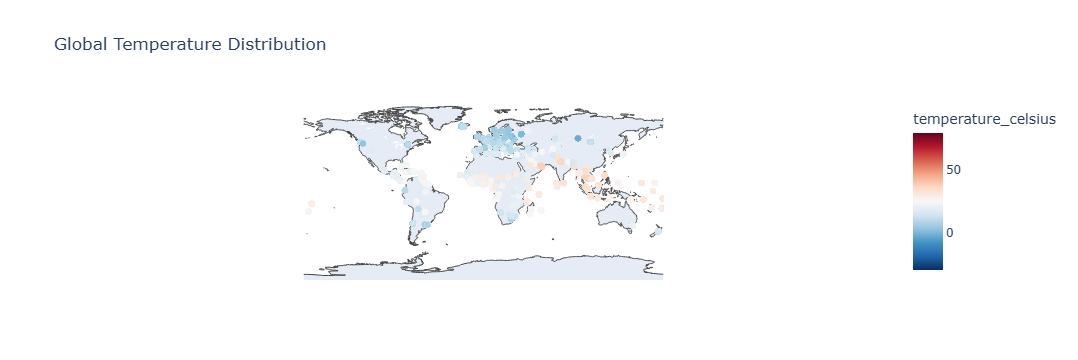

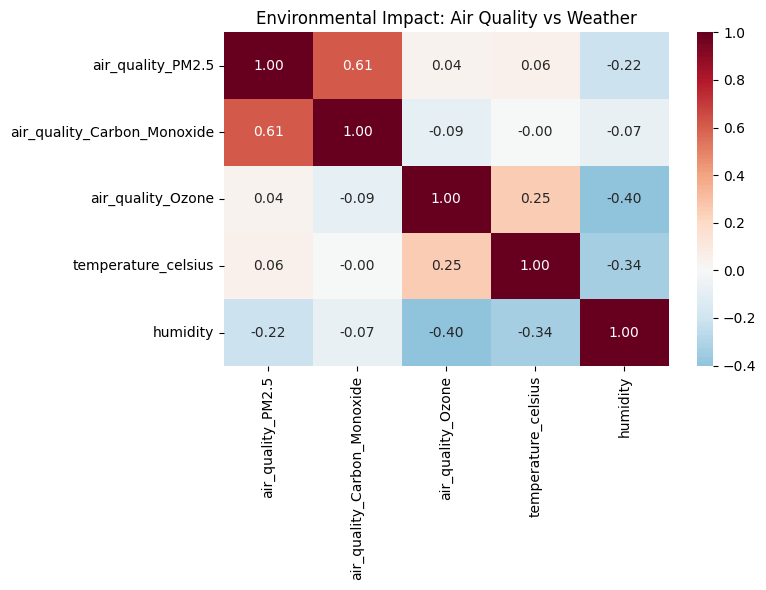

In [3]:
# Environmental Analysis
import matplotlib.pyplot as plt

fig_map = plot_spatial_weather(df)
fig_map.show()

plot_air_quality_correlation(df)
plt.show()

XGBoost RMSE: 0.92°C


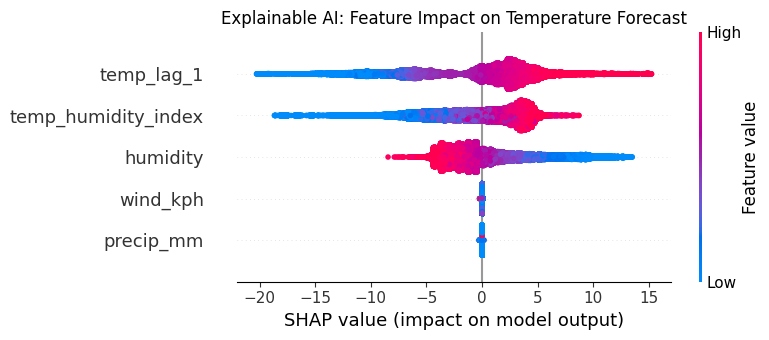

In [6]:
# ML and Explainability
train_size = int(len(df) * 0.8)
train_df, test_df = df.iloc[:train_size], df.iloc[train_size:]
features = ['temp_lag_1', 'humidity', 'wind_kph', 'precip_mm', 'temp_humidity_index']
xgb_model, X_train = train_xgboost_model(train_df, test_df, features)
generate_shap_explanation(xgb_model, X_train)
plt.show()

23:54:08 - cmdstanpy - INFO - Chain [1] start processing
23:54:08 - cmdstanpy - INFO - Chain [1] done processing


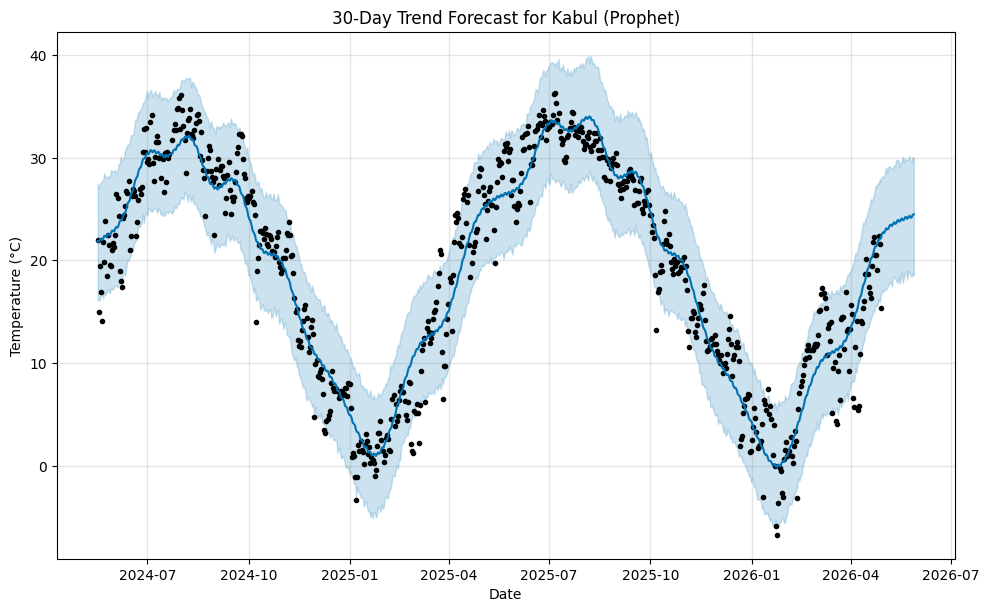

In [5]:
# Trend Forecasting
city = "Kabul"
prophet_model, forecast_data = train_prophet_model(df, location=city)
plot_prophet_forecast(prophet_model, forecast_data, city)
plt.show()